In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

In [ ]:
aws_land_raw = pd.read_csv("validation_sheet_Land.csv")
aws_ice_raw = pd.read_csv("validation_sheet_ice.csv")

In [ ]:
period_start = "2022-07-01"
period_end = "2022-12-31"

In [ ]:
print(aws_ice_raw["aws"].value_counts())
print(aws_land_raw["aws"].value_counts())

In [ ]:
aws_ice_raw["date"] = pd.to_datetime(aws_ice_raw["date"])

aws_ice = aws_ice_raw[
    (aws_ice_raw["date"] >= period_start) &
    (aws_ice_raw["date"] <= period_end)
].copy()

aws_land_raw["date"] = pd.to_datetime(aws_land_raw["Date"])
aws_land = aws_land_raw[
    (aws_land_raw["date"] >= period_start) &
    (aws_land_raw["date"] <= period_end)
].copy()

print(len(aws_ice))
print(len(aws_land))

In [ ]:
# ERA5
era5_land_raw = pd.read_csv("/home/sirsimsius/Dokumente/Arbeit/KU/GEMLST/GEMLST_MODIS/Data/ERA5/t2m_at_GEM_full.csv")
era5_ice_raw = pd.read_csv("/home/sirsimsius/Dokumente/Arbeit/KU/GEMLST/GEMLST_MODIS/Data/ERA5/t2m_at_PROMICE_full.csv")

def filter_era5_data(era5_raw, period_start, period_end):
    era5_raw["date"] = pd.to_datetime(era5_raw["id"])
    era5_filtered = era5_raw[
        (era5_raw["date"] >= period_start) &
        (era5_raw["date"] <= period_end)
    ].copy()
    return era5_filtered

def filter_era5_ice(era5_raw, period_start, period_end):
    era5_raw["date"] = pd.to_datetime(era5_raw["Unnamed: 0"])
    era5_filtered = era5_raw[
        (era5_raw["date"] >= period_start) &
        (era5_raw["date"] <= period_end)
    ].copy()
    return era5_filtered

era5_land = filter_era5_data(era5_land_raw, period_start, period_end)
era5_ice = filter_era5_ice(era5_ice_raw, period_start, period_end)

# era5_land.head()
# print(era5_ice_raw.columns)

In [ ]:
# JAXA G-COM 
sgli_land_a_raw = pd.read_csv("/home/sirsimsius/Dokumente/Arbeit/KU/GEMLST/GEMLST_MODIS/Data/LST_Extractions/JAXA/GEM_2024_AWS_JAXA_A_LST.csv")
sgli_land_d_raw = pd.read_csv("/home/sirsimsius/Dokumente/Arbeit/KU/GEMLST/GEMLST_MODIS/Data/LST_Extractions/JAXA/GEM_2024_AWS_JAXA_D_LST.csv")
sgli_ice_a_raw = pd.read_csv("/home/sirsimsius/Dokumente/Arbeit/KU/GEMLST/GEMLST_MODIS/Data/LST_Extractions/JAXA/JAXA_A_LST_PROMICE.csv")
sgli_ice_d_raw = pd.read_csv("/home/sirsimsius/Dokumente/Arbeit/KU/GEMLST/GEMLST_MODIS/Data/LST_Extractions/JAXA/JAXA_D_LST_PROMICE.csv")

def filter_sgli_data(df, station, period_start, period_end):
    df["date"] = pd.to_datetime(df["date"])
    filtered_df = df[
        (df["id"] == station) &
        (df["date"] >= period_start) &
        (df["date"] <= period_end)
    ].copy()
    return filtered_df

sgli_land_a = filter_sgli_data(sgli_land_a_raw, station_land, period_start, period_end)
sgli_land_d = filter_sgli_data(sgli_land_d_raw, station_land, period_start, period_end)
sgli_ice_a = filter_sgli_data(sgli_ice_a_raw, station_ice, period_start, period_end)
sgli_ice_d = filter_sgli_data(sgli_ice_d_raw, station_ice, period_start, period_end)

print(len(sgli_land_a))
print(len(sgli_land_d))
print(len(sgli_ice_a))
print(len(sgli_ice_d))


In [ ]:
mod_day_land_raw = pd.read_csv("/home/sirsimsius/Dokumente/Arbeit/KU/GEMLST/GEMLST_MODIS/Data/LST_Extractions/MODIS/GEM_2022_AWS_MOD_DAY_LST_bit6lte1.csv")
mod_night_land_raw = pd.read_csv("/home/sirsimsius/Dokumente/Arbeit/KU/GEMLST/GEMLST_MODIS/Data/LST_Extractions/MODIS/GEM_2022_AWS_MOD_NIGHT_LST_bit6lte1.csv")
mod_day_ice_raw = pd.read_csv("/home/sirsimsius/Dokumente/Arbeit/KU/GEMLST/GEMLST_MODIS/Data/LST_Extractions/MODIS/MOD_DAY_LST_PROMICE_after2022.csv")
mod_night_ice_raw = pd.read_csv("/home/sirsimsius/Dokumente/Arbeit/KU/GEMLST/GEMLST_MODIS/Data/LST_Extractions/MODIS/MOD_NIGHT_LST_PROMICE_after2022.csv")

myd_day_land_raw = pd.read_csv("/home/sirsimsius/Dokumente/Arbeit/KU/GEMLST/GEMLST_MODIS/Data/LST_Extractions/MODIS/GEM_2022_AWS_MYD_DAY_LST_bit6lte1.csv")
myd_night_land_raw = pd.read_csv("/home/sirsimsius/Dokumente/Arbeit/KU/GEMLST/GEMLST_MODIS/Data/LST_Extractions/MODIS/GEM_2022_AWS_MYD_NIGHT_LST_bit6lte1.csv")
myd_day_ice_raw = pd.read_csv("/home/sirsimsius/Dokumente/Arbeit/KU/GEMLST/GEMLST_MODIS/Data/LST_Extractions/MODIS/MYD_DAY_LST_PROMICE_after2022.csv")
myd_night_ice_raw = pd.read_csv("/home/sirsimsius/Dokumente/Arbeit/KU/GEMLST/GEMLST_MODIS/Data/LST_Extractions/MODIS/MYD_NIGHT_LST_PROMICE_after2022.csv")

def filter_modis_data(df, station, period_start, period_end):
    df["date"] = pd.to_datetime(df["date"])
    filtered_df = df[
        (df["id"] == station) &
        (df["date"] >= period_start) &
        (df["date"] <= period_end)
    ].copy()
    return filtered_df

mod_day_land = filter_modis_data(mod_day_land_raw, station_land, period_start, period_end)
mod_night_land = filter_modis_data(mod_night_land_raw, station_land, period_start, period_end)
mod_day_ice = filter_modis_data(mod_day_ice_raw, station_ice, period_start, period_end)
mod_night_ice = filter_modis_data(mod_night_ice_raw, station_ice, period_start, period_end)

myd_day_land = filter_modis_data(myd_day_land_raw, station_land, period_start, period_end)
myd_night_land = filter_modis_data(myd_night_land_raw, station_land, period_start, period_end)
myd_day_ice = filter_modis_data(myd_day_ice_raw, station_ice, period_start, period_end)
myd_night_ice = filter_modis_data(myd_night_ice_raw, station_ice, period_start, period_end)

print(len(mod_day_land))
print(len(mod_night_land))
print(len(mod_day_ice))
print(len(mod_night_ice))
print(len(myd_day_land))
print(len(myd_night_land))
print(len(myd_day_ice))
print(len(myd_night_ice))

In [ ]:
viirs_day_land_raw = pd.read_csv("/home/sirsimsius/Dokumente/Arbeit/KU/GEMLST/GEMLST_MODIS/Data/LST_Extractions/VIIRS/GEM_AWS_VIIRS_DAY_LST.csv")
viirs_night_land_raw = pd.read_csv("/home/sirsimsius/Dokumente/Arbeit/KU/GEMLST/GEMLST_MODIS/Data/LST_Extractions/VIIRS/GEM_AWS_VIIRS_NIGHT_LST.csv")
viirs_day_ice_raw = pd.read_csv("/home/sirsimsius/Dokumente/Arbeit/KU/GEMLST/GEMLST_MODIS/Data/LST_Extractions/VIIRS/VIIRS_DAY_LST_PROMICE.csv")
viirs_night_ice_raw = pd.read_csv("/home/sirsimsius/Dokumente/Arbeit/KU/GEMLST/GEMLST_MODIS/Data/LST_Extractions/VIIRS/VIIRS_NIGHT_LST_PROMICE.csv")

def filter_viirs_data(df, station, period_start, period_end):
    df["date"] = pd.to_datetime(df["date"])
    filtered_df = df[
        (df["id"] == station) &
        (df["date"] >= period_start) &
        (df["date"] <= period_end)
    ].copy()
    return filtered_df

viirs_day_land = filter_viirs_data(viirs_day_land_raw, station_land, period_start, period_end)
viirs_night_land = filter_viirs_data(viirs_night_land_raw, station_land, period_start, period_end)
viirs_day_ice = filter_viirs_data(viirs_day_ice_raw, station_ice, period_start, period_end)
viirs_night_ice = filter_viirs_data(viirs_night_ice_raw, station_ice, period_start, period_end)

print(len(viirs_day_land))
print(len(viirs_night_land))
print(len(viirs_day_ice))
print(len(viirs_night_ice))

In [ ]:
# Create stats for both datasets: Number of observatoins, Bias, RMSE, R2
from sklearn.metrics import r2_score

stats_ice = {
    "N": len(aws_ice),
    "bias": aws_ice["t_surf"].mean() - aws_ice["RS_LST"].mean(),
    "rmse": np.sqrt(np.mean((aws_ice["t_surf"] - aws_ice["RS_LST"]) ** 2)),
    "$R^2$": r2_score(aws_ice["t_surf"], aws_ice["RS_LST"])
}

stats_land = {
    "N": len(aws_land),
    "bias": aws_land["temperature"].mean() - aws_land["RS_LST"].mean(),
    "rmse": np.sqrt(np.mean((aws_land["temperature"] - aws_land["RS_LST"]) ** 2)),
    "$R^2$": r2_score(aws_land["temperature"], aws_land["RS_LST"])
}

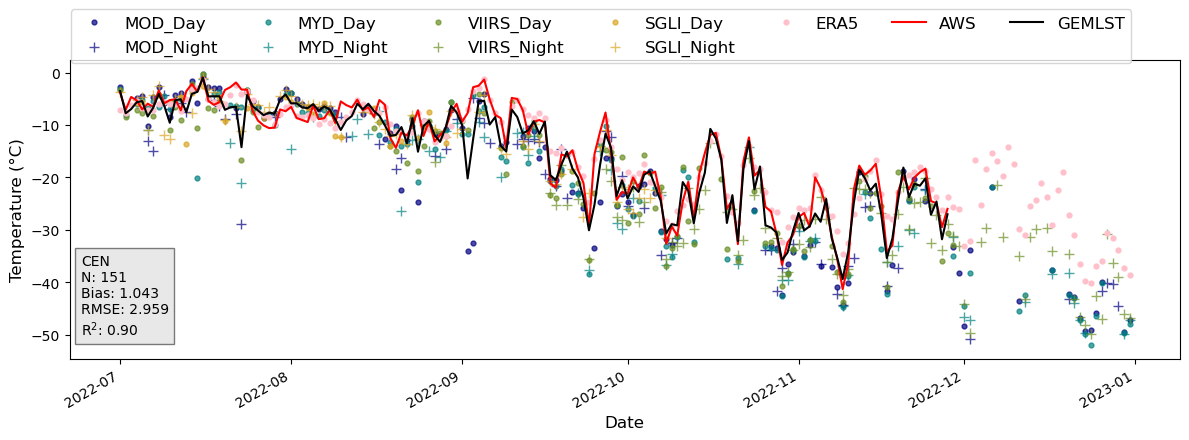

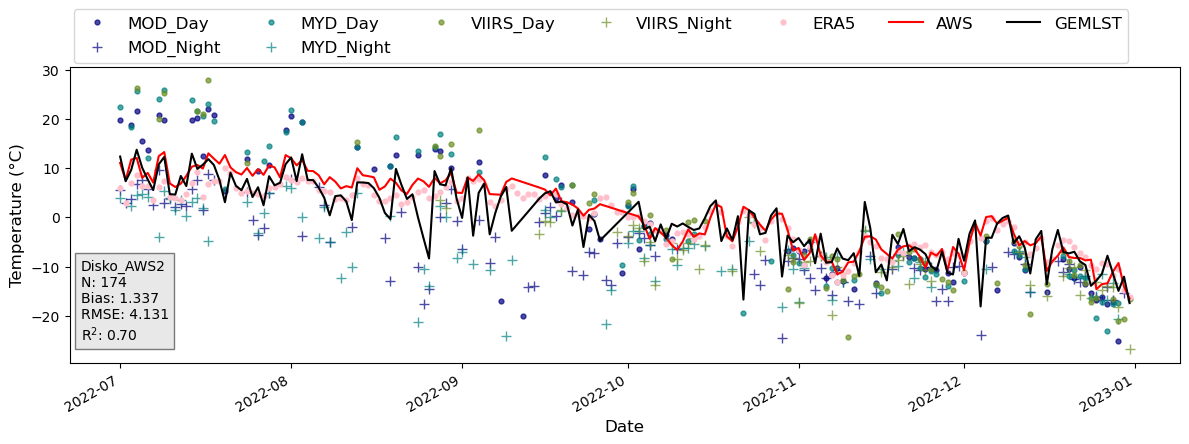

In [36]:
# Create one time-series plot for every ice station.
for station_ice in sorted(aws_ice_raw["aws"].dropna().unique())[:1]:
    aws_ice = aws_ice_raw[
        (aws_ice_raw["aws"] == station_ice) &
        (aws_ice_raw["date"] >= period_start) &
        (aws_ice_raw["date"] <= period_end)
    ].copy()

    mod_day = filter_modis_data(mod_day_ice_raw, station_ice, period_start, period_end)
    mod_night = filter_modis_data(mod_night_ice_raw, station_ice, period_start, period_end)
    myd_day = filter_modis_data(myd_day_ice_raw, station_ice, period_start, period_end)
    myd_night = filter_modis_data(myd_night_ice_raw, station_ice, period_start, period_end)
    viirs_day = filter_viirs_data(viirs_day_ice_raw, station_ice, period_start, period_end)
    viirs_night = filter_viirs_data(viirs_night_ice_raw, station_ice, period_start, period_end)
    sgli_a = filter_sgli_data(sgli_ice_a_raw, station_ice, period_start, period_end)
    sgli_d = filter_sgli_data(sgli_ice_d_raw, station_ice, period_start, period_end)
    era5 = era5_ice[era5_ice["date"].between(period_start, period_end)].copy()

    valid_stats = aws_ice[["t_surf", "RS_LST"]].dropna()
    stats = {
        "N": len(aws_ice),
        "bias": aws_ice["t_surf"].mean() - aws_ice["RS_LST"].mean(),
        "rmse": np.sqrt(np.mean((aws_ice["t_surf"] - aws_ice["RS_LST"]) ** 2)),
        "$R^2$": r2_score(valid_stats["t_surf"], valid_stats["RS_LST"]) if len(valid_stats) >= 2 else np.nan,
    }
    stats_text = (
        f"{station_ice}\n"
        f"N: {stats['N']}\n"
        f"Bias: {stats['bias']:.3f}\n"
        f"RMSE: {stats['rmse']:.3f}\n"
        f"R$^2$: {stats['$R^2$']:.2f}"
    )

    fig, ax = plt.subplots(figsize=(12, 4))
    mod_day.plot(x="date", y="MOD_LST_Day", ax=ax, color="navy", linestyle="None", marker=".", markersize=7, alpha=0.7, label="MOD_Day", legend=False)
    mod_night.plot(x="date", y="MOD_LST_Night", ax=ax, color="navy", linestyle="None", marker="+", markersize=7, alpha=0.7, label="MOD_Night", legend=False)
    myd_day.plot(x="date", y="MYD_LST_Day", ax=ax, color="teal", linestyle="None", marker=".", markersize=7, alpha=0.7, label="MYD_Day", legend=False)
    myd_night.plot(x="date", y="MYD_LST_Night", ax=ax, color="teal", linestyle="None", marker="+", markersize=7, alpha=0.7, label="MYD_Night", legend=False)
    viirs_day.plot(x="date", y="VIIRS_LST_1KM_C", ax=ax, color="olivedrab", linestyle="None", marker=".", markersize=7, alpha=0.7, label="VIIRS_Day", legend=False)
    viirs_night.plot(x="date", y="VIIRS_LST_1KM_C", ax=ax, color="olivedrab", linestyle="None", marker="+", markersize=7, alpha=0.7, label="VIIRS_Night", legend=False)
    sgli_a.plot(x="date", y="JAXA_LST_AVE", ax=ax, color="goldenrod", linestyle="None", marker=".", markersize=7, alpha=0.7, label="SGLI_Day", legend=False)
    sgli_d.plot(x="date", y="JAXA_LST_AVE", ax=ax, color="goldenrod", linestyle="None", marker="+", markersize=7, alpha=0.7, label="SGLI_Night", legend=False)
    if station_ice in era5.columns:
        era5.plot(x="date", y=station_ice, ax=ax, color="pink", linestyle="None", marker=".", markersize=7, label="ERA5", legend=False)
    aws_ice.plot(x="date", y="t_surf", ax=ax, color="red", label="AWS", linewidth=1.5, legend=False)
    aws_ice.plot(x="date", y="RS_LST", ax=ax, color="black", label="GEMLST", linewidth=1.5, legend=False)
    ax.text(0.01, 0.35, stats_text, transform=ax.transAxes, fontsize=10, verticalalignment="top", bbox=dict(facecolor="lightgrey", alpha=0.5))
    ax.set_ylabel("Temperature (°C)", size=12)
    ax.set_xlabel("Date", size=12)

    # Create one legend for both subplots
    handles, labels = ax.get_legend_handles_labels()
    # Create a dictionary to remove duplicates while preserving order
    unique_labels = dict(zip(labels, handles))
    # Create a single legend for both subplots
    fig.legend(
        unique_labels.values(),
        unique_labels.keys(),
        loc="upper center",
        bbox_to_anchor=(0.505, 1.11),
        ncol=7,
        fontsize=12,
        # edgecolor='black', framealpha=0.5
)
    fig.tight_layout()
    # fig.savefig(f"Time_series_{station_ice}.png", dpi=300)
    # fig.savefig(f"Time_series_{station_ice}.pdf", dpi=300)
    plt.show()
    plt.close(fig)

# Create one time-series plot for every land station.
for station_land in sorted(aws_land_raw["aws"].dropna().unique())[:1]:
    aws_land = aws_land_raw[
        (aws_land_raw["aws"] == station_land) &
        (aws_land_raw["date"] >= period_start) &
        (aws_land_raw["date"] <= period_end)
    ].copy()

    mod_day = filter_modis_data(mod_day_land_raw, station_land, period_start, period_end)
    mod_night = filter_modis_data(mod_night_land_raw, station_land, period_start, period_end)
    myd_day = filter_modis_data(myd_day_land_raw, station_land, period_start, period_end)
    myd_night = filter_modis_data(myd_night_land_raw, station_land, period_start, period_end)
    viirs_day = filter_viirs_data(viirs_day_land_raw, station_land, period_start, period_end)
    viirs_night = filter_viirs_data(viirs_night_land_raw, station_land, period_start, period_end)
    era5 = era5_land[era5_land["date"].between(period_start, period_end)].copy()

    valid_stats = aws_land[["temperature", "RS_LST"]].dropna()
    stats = {
        "N": len(aws_land),
        "bias": aws_land["temperature"].mean() - aws_land["RS_LST"].mean(),
        "rmse": np.sqrt(np.mean((aws_land["temperature"] - aws_land["RS_LST"]) ** 2)),
        "$R^2$": r2_score(valid_stats["temperature"], valid_stats["RS_LST"]) if len(valid_stats) >= 2 else np.nan,
    }
    stats_text = (
        f"{station_land}\n"
        f"N: {stats['N']}\n"
        f"Bias: {stats['bias']:.3f}\n"
        f"RMSE: {stats['rmse']:.3f}\n"
        f"R$^2$: {stats['$R^2$']:.2f}"
    )

    fig, ax = plt.subplots(figsize=(12, 4))
    
    mod_day.plot(x="date", y="MOD_LST_Day", ax=ax, color="navy", linestyle="None", marker=".", markersize=7, alpha=0.7, label="MOD_Day", legend=False)
    mod_night.plot(x="date", y="MOD_LST_Night", ax=ax, color="navy", linestyle="None", marker="+", markersize=7, alpha=0.7, label="MOD_Night", legend=False)
    myd_day.plot(x="date", y="MYD_LST_Day", ax=ax, color="teal", linestyle="None", marker=".", markersize=7, alpha=0.7, label="MYD_Day", legend=False)
    myd_night.plot(x="date", y="MYD_LST_Night", ax=ax, color="teal", linestyle="None", marker="+", markersize=7, alpha=0.7, label="MYD_Night", legend=False)
    viirs_day.plot(x="date", y="VIIRS_LST_1KM_C", ax=ax, color="olivedrab", linestyle="None", marker=".", markersize=7, alpha=0.7, label="VIIRS_Day", legend=False)
    viirs_night.plot(x="date", y="VIIRS_LST_1KM_C", ax=ax, color="olivedrab", linestyle="None", marker="+", markersize=7, alpha=0.7, label="VIIRS_Night", legend=False)
    if station_land in era5.columns:
            era5.plot(x="date", y=station_land, ax=ax, color="pink", linestyle="None", marker=".", markersize=7, label="ERA5", legend=False)
    aws_land.plot(x="date", y="temperature", ax=ax, color="red", label="AWS", linewidth=1.5, legend=False)
    aws_land.plot(x="date", y="RS_LST", ax=ax, color="black", label="GEMLST", linewidth=1.5, legend=False)
    ax.text(0.01, 0.35, stats_text, transform=ax.transAxes, fontsize=10, verticalalignment="top", bbox=dict(facecolor="lightgrey", alpha=0.5))
    ax.set_ylabel("Temperature (°C)", size=12)
    ax.set_xlabel("Date", size=12)

    # Create one legend for both subplots
    handles, labels = ax.get_legend_handles_labels()
    # Create a dictionary to remove duplicates while preserving order
    unique_labels = dict(zip(labels, handles))
    # Create a single legend for both subplots
    fig.legend(
        unique_labels.values(),
        unique_labels.keys(),
        loc="upper center",
        bbox_to_anchor=(0.505, 1.12),
        ncol=7,
        fontsize=12,
        # edgecolor='black', framealpha=0.5
)
    fig.tight_layout()
    # fig.savefig(f"Time_series_{station_land}.png", dpi=300)
    # fig.savefig(f"Time_series_{station_land}.pdf", dpi=300)
    plt.show()
    plt.close(fig)